In [8]:
import sys
sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

### Try MPF for the trotter evolution (?)

### Try differently

In [9]:
service = QiskitRuntimeService(instance="client-enablement/solutions/demo-testing")
backend = service.backend("ibm_torino")

qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27]  # trying 1 loop for torino
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
rev_map = {val: key for key, val in remap.items()}

cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()


H = Heisenberg(1, 12, edge_list)


# def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
#     qc.cx(12, 9)
#     qc.cx(9, 10)
#     qc.cx(10, 11)
#     qc.cx(9, 8)
#     qc.cx(11, 6)
#     qc.cx(8, 7)
#     qc.cx(7, 5)
#     qc.cx(6, 4)
#     qc.cx(4, 3)
#     qc.cx(5, 0)
#     qc.cx(3, 2)
#     # make checkpoints
#     qc.cx(11, 17)
#     qc.cx(4, 16)
#     qc.cx(2, 15)
#     qc.cx(0, 14)
#     qc.cx(7, 13)
#     # undo entanglement on undesired qubits
#     qc.cx(2, 3)
#     qc.cx(4, 6)
#     qc.cx(11, 10)
#     qc.cx(9, 8)
#     qc.cx(7, 5)
#     return qc


# def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
#     qc.cx(12, 9, ctrl_state="0")
#     qc.cx(17, 11, ctrl_state="0")
#     qc.cx(16, 4, ctrl_state="0")
#     qc.cx(15, 2, ctrl_state="0")
#     qc.cx(14, 0, ctrl_state="0")
#     qc.cx(13, 7, ctrl_state="0")
#     return qc

def prep_psi_0(qc: QuantumCircuit):
    qc.cx(12, 0)
    qc.cx(13,2)
    return qc

def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(12, 0, ctrl_state="0")
    qc.cx(13,2,ctrl_state="0")
    return qc

In [10]:
from qiskit_aer import StatevectorSimulator 

sv = StatevectorSimulator()
qc = QuantumCircuit(14)
qc.h(12)
qc.cx(12,13)
qc = prep_psi_0(qc)
#qc = prep_psi_0_by_0(qc)
#print(qc)


job = sv.run(circuits=qc)
res = job.result()

res.get_counts()




{np.str_('00000000000000'): np.float64(0.5),
 np.str_('11000000000101'): np.float64(0.5)}

In [11]:
qc = prep_psi_0_by_0(qc)
job = sv.run(circuits=qc)
res = job.result()

res.get_counts()

{np.str_('00000000000101'): np.float64(0.5),
 np.str_('11000000000101'): np.float64(0.5)}

In [12]:
from qiskit.transpiler import generate_preset_pass_manager

t_steps = 8
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp("XX", 1) ^ H
imag_obs_H = SparsePauliOp("YX", 1) ^ H
real_obs_S = SparsePauliOp("XX", 1) ^ SparsePauliOp("I" * 12, 1)
imag_obs_S = SparsePauliOp("YX", 1) ^ SparsePauliOp("I" * 12, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        #qc = QuantumCircuit(18)
        qc = QuantumCircuit(14)
        qc.h(12)
        qc.cx(12,13)
       # qc = prep_psi_0_with_checkpoints(qc)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(12))
        #qc = prep_psi_0_by_0_with_checkpoints(qc)
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

In [13]:
f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"

'Max circuit depth:72'

In [10]:
f"Max number of 2q gates= {max([circs[i][j].num_nonlocal_gates() for i in range(t_steps) for j in range(t_steps)])}"

'Max number of 2q gates= 307'

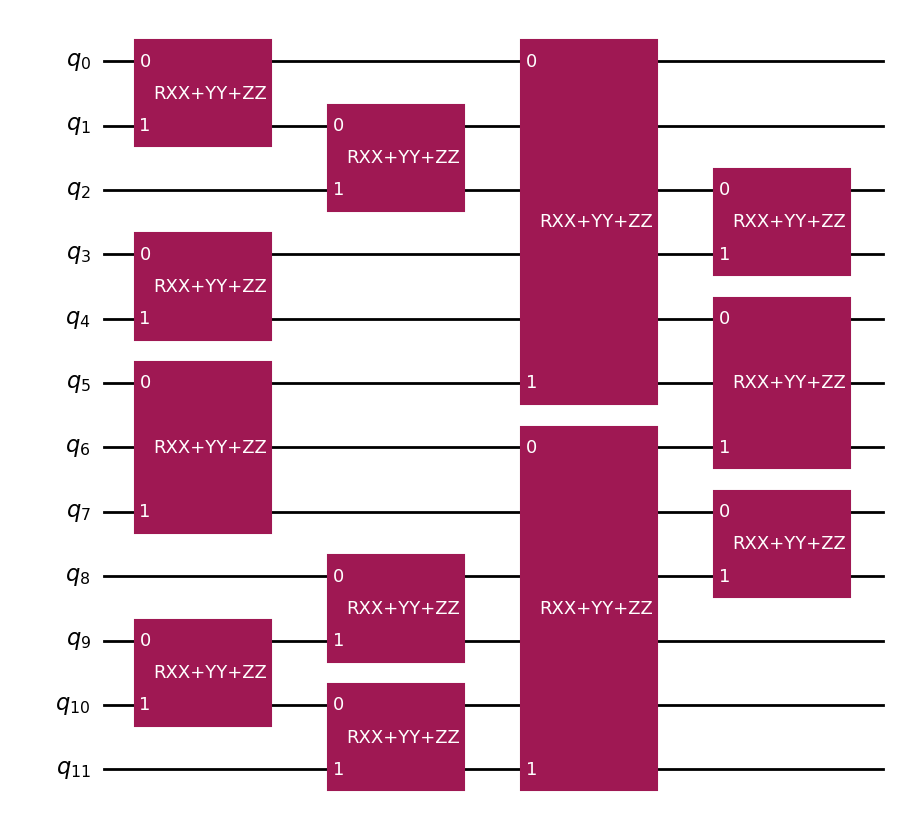

In [94]:
time_evol.draw("mpl")

### Try AQC-tensor to compress trotter step

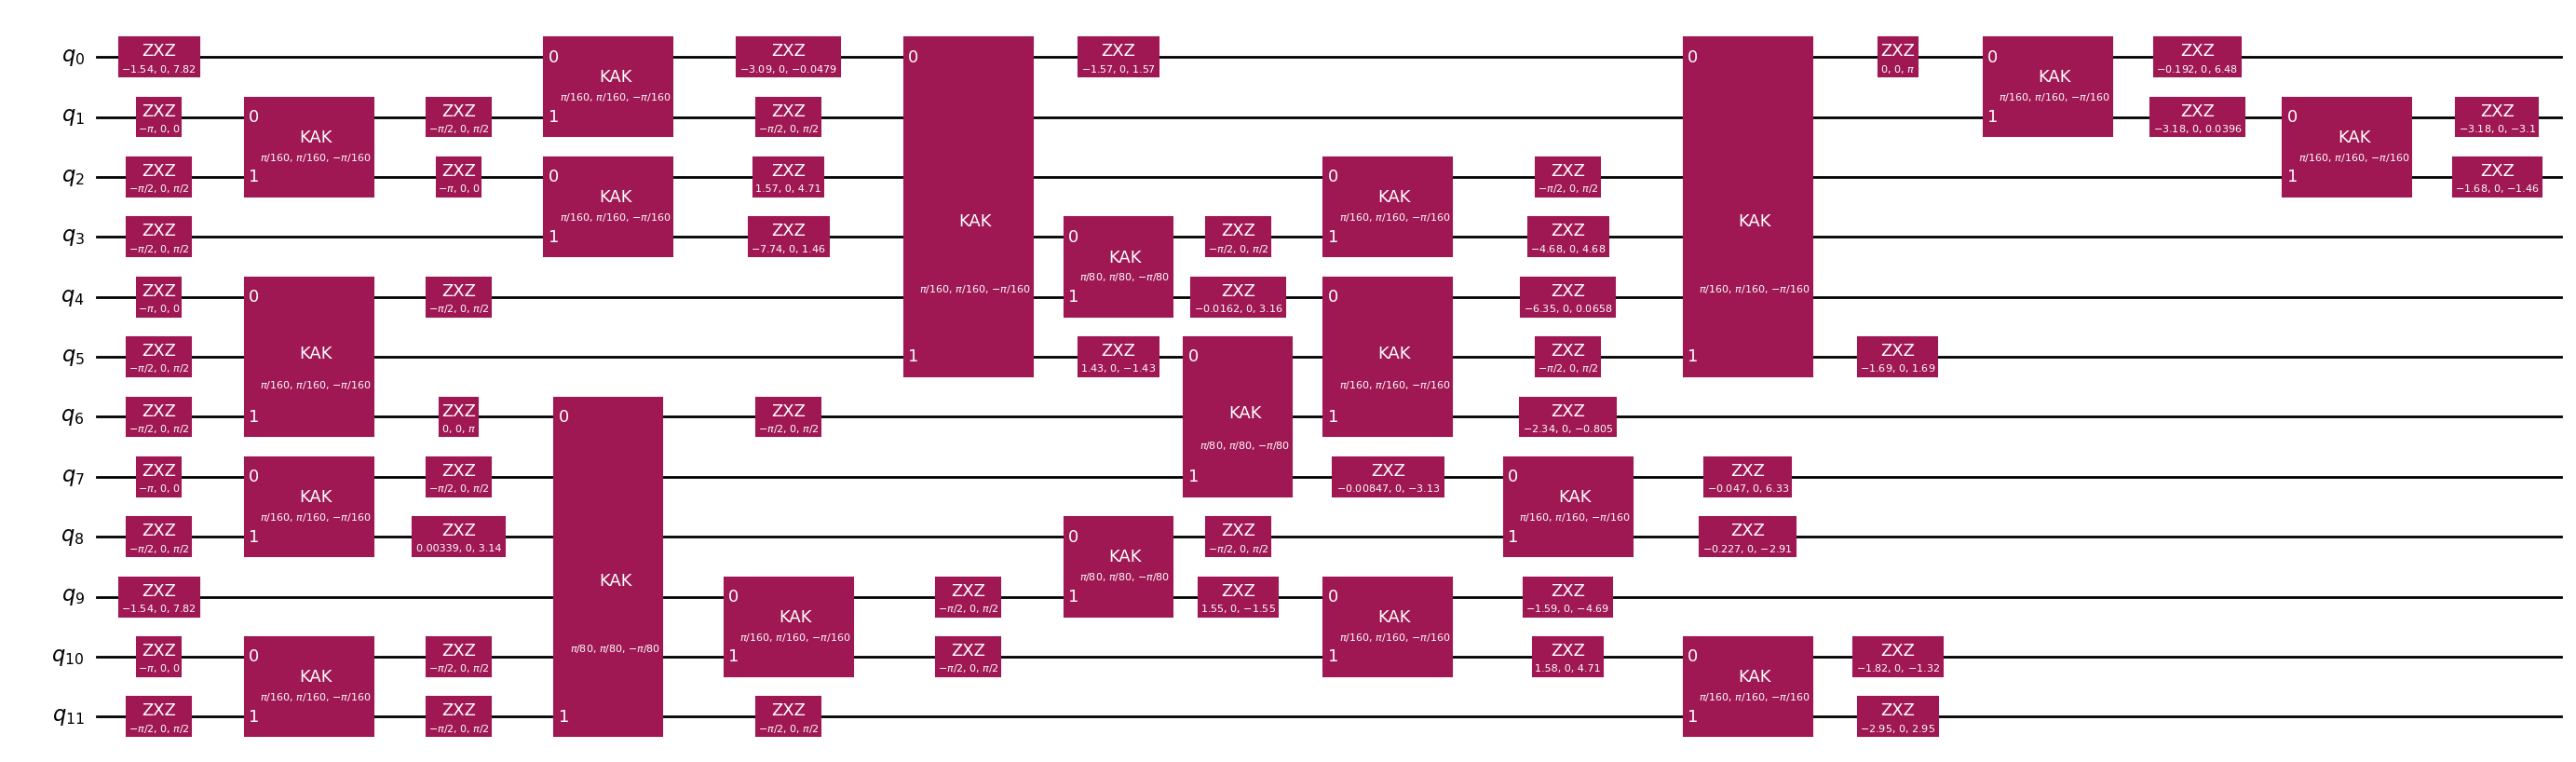

In [ ]:
from qiskit_addon_aqc_tensor import generate_ansatz_from_circuit
from qiskit.synthesis import SuzukiTrotter
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit


aqc_good_circuit = generate_time_evolution_circuit(
    H,
    synthesis=SuzukiTrotter(reps=1),
    time=delta_t/2,
)

aqc_ansatz, aqc_initial_parameters = generate_ansatz_from_circuit(
    aqc_good_circuit, parameter_name="x"
)
aqc_ansatz.assign_parameters(aqc_initial_parameters).draw("mpl", fold=-1)

In [8]:
from functools import partial

import quimb.tensor

from qiskit_addon_aqc_tensor.simulation.quimb import QuimbSimulator

simulator_settings = QuimbSimulator(partial(quimb.tensor.Circuit), autodiff_backend="jax")

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/cotengra/hyperoptimizers/hyper.py:57: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/cotengra/hyperoptimizers/hyper.py:39: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/cotengra/hyperoptimizers/hyper.py:76: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


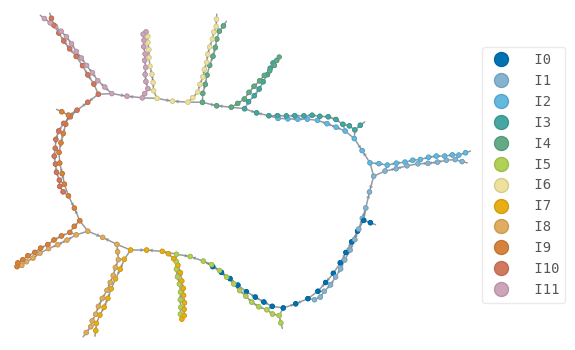

In [9]:
from qiskit_addon_aqc_tensor.simulation import tensornetwork_from_circuit

aqc_target_mpo = tensornetwork_from_circuit(orig_circuit.decompose(), simulator_settings).get_uni()
aqc_target_mpo.draw(aqc_target_mpo.site_tags, show_tags=False)

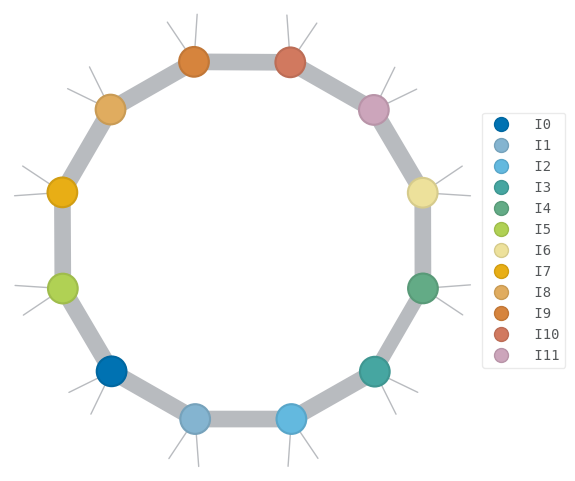

In [10]:
for site in aqc_target_mpo.site_tags:
    aqc_target_mpo ^= site
aqc_target_mpo.fuse_multibonds_()

aqc_target_mpo.draw(aqc_target_mpo.site_tags, show_tags=False)

In [ ]:
from scipy.optimize import OptimizeResult, minimize

from qiskit_addon_aqc_tensor.objective import MaximizeUnitaryFidelity

objective = MaximizeUnitaryFidelity(aqc_target_mpo, aqc_ansatz, simulator_settings)

stopping_point = 1e-4


def my_loss_function(*args):
    val, grad = objective.loss_function(*args)
    print(f"Evaluating loss function: {1 - val:.8}")
    return val, grad


def callback(intermediate_result: OptimizeResult):
    print(f"Intermediate result: Fidelity {1 - intermediate_result.fun:.8}")
    if intermediate_result.fun < stopping_point:
        # Good enough for now
        raise StopIteration


result = minimize(
    my_loss_function,
    aqc_initial_parameters,
    method="L-BFGS-B",
    jac=True,
    options={"maxiter": 100},
    callback=callback,
)
if result.status not in (
    0,
    1,
    99,
):  # 0 => success; 1 => max iterations reached; 99 => early termination via StopIteration
    raise RuntimeError(f"Optimization failed: {result.message} (status={result.status})")

print(f"Done after {result.nit} iterations.")
aqc_final_parameters = result.x

In [110]:
aqc_optimized_block = aqc_ansatz.assign_parameters(aqc_final_parameters)

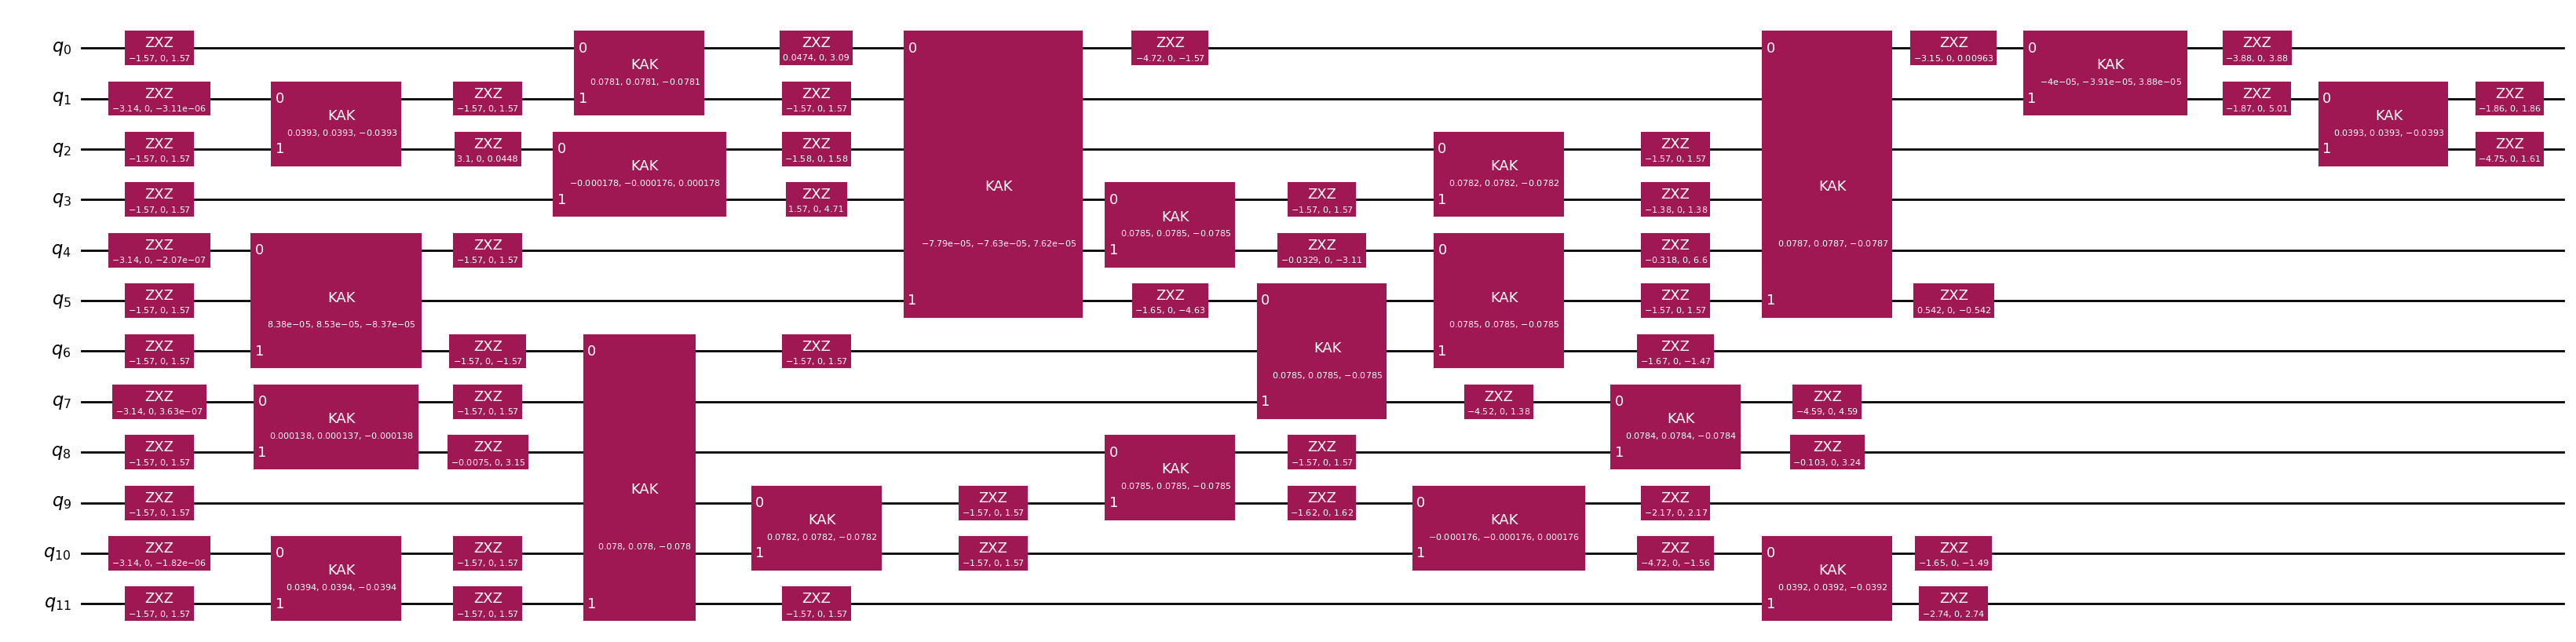

In [111]:
aqc_optimized_block.draw("mpl",fold=-1)

### Circuit execution

In [17]:
# basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

pub1 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[0:2]
    for circ in circ_list
]
pub2 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[2:4]
    for circ in circ_list
]
pub3 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[4:6]
    for circ in circ_list
]
pub4 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[6:8]
    for circ in circ_list
]



with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 30000
    estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.resilience.zne.noise_factors=(1,1.5,2) # use fractional folding
    estimator.options.resilience.zne.extrapolator='linear' # exponential fit showed high std's, use this instead.
    est_job_1 = estimator.run(pub1)
    est_job_2 = estimator.run(pub2)
    est_job_3 = estimator.run(pub3)
    est_job_4 = estimator.run(pub4)

In [18]:
# est_job_1_results = service.job(est_job_1.job_id()).result()

# est_job_2_results = service.job(est_job_2.job_id()).result()

# est_job_3_results = service.job(est_job_3.job_id()).result()

# est_job_4_results = service.job(est_job_4.job_id()).result()


est_job_1_results = service.job(est_job_1.job_id()).result()

est_job_2_results = service.job(est_job_2.job_id()).result()

est_job_3_results = service.job(est_job_3.job_id()).result()

est_job_4_results = service.job(est_job_4.job_id()).result()

In [ ]:
idx = 0
for i in range(2):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
        )
        idx += 1

idx = 0
for i in range(2, 4):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
        )
        idx += 1

idx = 0
for i in range(4, 6):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_3_results[idx].data.evs[0] + 1j * est_job_3_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_3_results[idx].data.evs[2] + 1j * est_job_3_results[idx].data.evs[3]
        )
        idx += 1

idx = 0
for i in range(6, 8):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_4_results[idx].data.evs[0] + 1j * est_job_4_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job__results[idx].data.evs[2] + 1j * est_job_4_results[idx].data.evs[3]
        )
        idx += 1

In [69]:
from sympy import Matrix
Matrix(S_tilde)

Matrix([
[      0.392803436986228 - 0.167701962246779*I,   0.00983771022802546 - 0.00318524003098812*I, 0.00590982310357203 + 0.000576295631493934*I,  1.82715994973389e-18 - 0.00248611197098718*I,  -8.73938535550972e-5 + 0.0142243153892738*I,  -0.00719124228203756 + 0.000746133717002115*I,  0.0140603459814865 - 0.000149140958066729*I,   0.00732528791420622 + 0.00193570061975238*I],
[   0.0108472465867662 + 0.00624571679865044*I,   0.0867272672942576 + 0.000223668371309127*I,  -0.00887973891411897 + 0.0201938952325254*I,   -0.00420984360040859 + 0.0045262416442019*I,   0.0053179647286035 - 0.00241475863934642*I,    0.0131635262081583 - 0.000694463983360426*I,  2.28975592472372e-17 + 0.0053283166891418*I,  0.00101673129848581 - 0.000113866378312855*I],
[  8.91384322836859e-5 - 0.00430743996026886*I,   0.00578897882503005 + 0.00383037669392949*I,   0.0117382299861214 - 0.00225222532081453*I,    0.0040957495941091 + 0.00247666045645601*I, -1.2930107385678e-17 - 0.00111138479493746*I,   0.0

In [70]:
Matrix(H_tilde)

Matrix([
[    -3.34399513502205 + 1.77078877741257*I, -0.0259638274224812 - 0.0582133811163607*I,  0.0830145980126243 + 0.0987356097114446*I,   -0.0418962277139455 + 0.10989794000945*I,      0.1123885015797 - 0.0879565353357156*I,     0.140078189459676 - 0.103874431542527*I, -0.0714628208707165 + 0.0372153669780467*I,  -0.0758362378195509 - 0.0970492147078084*I],
[  -0.189985036247741 - 0.112855506542614*I,   -0.875152185431522 + 0.148911281195704*I, -0.0151099868634502 - 0.0826602303232709*I,  -0.00322813990638961 - 0.14483762064072*I, 0.000736968979500071 - 0.0375822165464251*I,  -0.0583036985026116 - 0.0110825598117743*I, -0.0435544589963083 + 0.0530865987241166*I,    0.102258338617297 - 0.0493620134986481*I],
[7.31393710831172e-5 + 0.0182572437274228*I, 0.00125426360011988 - 0.0508386147841731*I,  -0.0879310097775249 + 0.109253287707213*I, -0.0337840376665378 + 0.0230278264613282*I,   -0.100824762436597 + 0.0552626495819371*I, -0.0684062602032018 + 0.00869145704484194*I,  0.0462416

1
[np.complex128(-8.828587225187455+0.7388361418333586j)]
(-8.828587225187455+0.7388361418333586j) (-8.828587225187455+0.7388361418333586j)
2
[np.complex128(-8.828587225187455+0.7388361418333586j), np.complex128(-9.96845112803906+1.9161271630736623j)]
(-9.96845112803906+1.9161271630736623j) (-8.966062084403424+0.5898867907209437j)
3
[np.complex128(-8.828587225187455+0.7388361418333586j), np.complex128(-9.96845112803906+1.9161271630736623j), np.complex128(-11.04865479638536+0.45139250853615215j)]
(-11.04865479638536+0.45139250853615215j) (-7.241016398121466+6.774561894142522j)
3
[np.complex128(-8.828587225187455+0.7388361418333586j), np.complex128(-9.96845112803906+1.9161271630736623j), np.complex128(-11.04865479638536+0.45139250853615215j), np.complex128(-10.16375808205916+0.3248563253635402j)]
(-10.16375808205916+0.3248563253635402j) (-5.360458214880634+5.466831277207321j)
3
[np.complex128(-8.828587225187455+0.7388361418333586j), np.complex128(-9.96845112803906+1.9161271630736623j), n

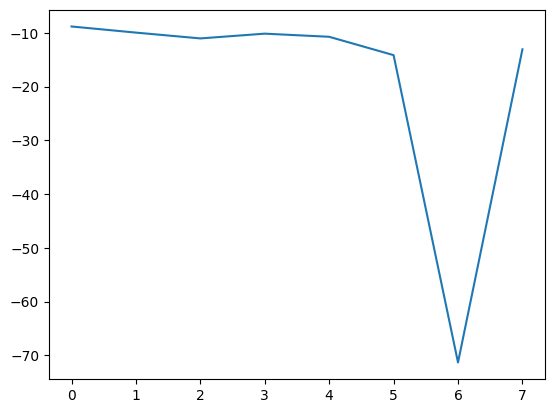

In [81]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]   
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    #make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T    
    return truncated_eigvecs

def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope*d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        #solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        print(A.shape[0])
        E, c = scipy.linalg.eig(a = A, b = B)
        idx = E.argsort()[::-1]   
        eigvals = E[idx]
        eigvecs = c[:,idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:,-1])
        print(GSEs)
        print(min(eigvals), max(eigvals))
    return GSEs, ground_states, V_eps
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-7)
plt.plot(GSEs)

# Run on simulator for comparison

In [414]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator

t_steps = 8
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp("XX", 1) ^ H
imag_obs_H = SparsePauliOp("YX", 1) ^ H
real_obs_S = SparsePauliOp("XX", 1) ^ SparsePauliOp("I" * 12, 1)
imag_obs_S = SparsePauliOp("YX", 1) ^ SparsePauliOp("I" * 12, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(14)
        qc.h(12)
        qc.cx(12,13)
        qc = prep_psi_0(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])


sv = StatevectorEstimator()
sv_job = sv.run(
    [
        (circs[i][j], [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S])
        for i in range(t_steps)
        for j in range(t_steps)
    ]
)

sv_res = sv_job.result()

In [415]:
idx = 0
for i in range(t_steps):
    for j in range(t_steps):
        H_tilde[i, j] = sv_res[idx].data.evs[0] + 1j * sv_res[idx].data.evs[1]
        S_tilde[i, j] = sv_res[idx].data.evs[2] + 1j * sv_res[idx].data.evs[3]
        idx += 1

Matrix(S_tilde)

Matrix([
[                                     1.0,  0.769905377185946 + 0.559368999065598*I,   0.23913780199077 + 0.781983595155085*I, -0.242899773756666 + 0.581218705199855*I, -0.407809221569859 + 0.158705404858155*I, -0.244737153390209 - 0.184120262638325*I, 0.0492481815946049 - 0.277290658768848*I,  0.263715782089072 - 0.161234186706513*I],
[ 0.769905377185946 + 0.559368999065598*I,                        0.999999999999999,  0.769905377185945 + 0.559368999065597*I,   0.23913780199077 + 0.781983595155084*I, -0.242899773756666 + 0.581218705199855*I, -0.407809221569859 + 0.158705404858156*I, -0.244737153390208 - 0.184120262638325*I, 0.0492481815946048 - 0.277290658768847*I],
[  0.23913780199077 + 0.781983595155085*I,  0.769905377185945 + 0.559368999065597*I,                        0.999999999999998,  0.769905377185945 + 0.559368999065596*I,  0.239137801990769 + 0.781983595155084*I, -0.242899773756665 + 0.581218705199854*I, -0.407809221569859 + 0.158705404858155*I, -0.244737153390208 -

In [416]:
Matrix(H_tilde)

Matrix([
[                                    4.0,     3.66805796237085 + 1.18387292796925*I,     2.83753200467841 + 2.06528501804281*I,     1.69664400834254 + 2.40062484152147*I,    0.611281907574174 + 2.04701821913774*I,   0.0383503684304596 + 1.15204070713846*I, 0.239968530743943 + 0.198479196346058*I,    1.03806467137951 - 0.249403069056484*I],
[  3.66805796237085 + 1.18387292796925*I, 3.90918218399933 - 1.82145964977565e-17*I,     3.60418215962366 + 1.14418756269939*I,      2.81561456074216 + 2.0185857439036*I,     1.70257018995592 + 2.37684024843455*I,    0.616663033040145 + 2.05350573399923*I, 0.0227465453545186 + 1.17434694576028*I,   0.200991357871078 + 0.216303346714237*I],
[  2.83753200467841 + 2.06528501804281*I,     3.60418215962366 + 1.14418756269939*I, 3.84962611036496 - 1.35460825919164e-17*I,     3.57482869686762 + 1.12314800324761*I,      2.81783654595868 + 2.0077516650877*I,     1.71364772157984 + 2.39540215787002*I,   0.60973533100036 + 2.09571374103088*I,  -0.01312

1
[np.complex128(4+0j)]
(4+0j) (4+0j)
2
[np.complex128(4+0j), np.complex128(1.989925634620877-0.3072218109481616j)]
(1.989925634620877-0.3072218109481616j) (4.108341680269098-0.6286551289240419j)
3
[np.complex128(4+0j), np.complex128(1.989925634620877-0.3072218109481616j), np.complex128(1.76917936938068-0.1605397161095245j)]
(1.76917936938068-0.1605397161095245j) (4.359900226758294-1.06411301839004j)
4
[np.complex128(4+0j), np.complex128(1.989925634620877-0.3072218109481616j), np.complex128(1.76917936938068-0.1605397161095245j), np.complex128(1.708450844711191-0.40644969785781937j)]
(1.708450844711191-0.40644969785781937j) (4.629948845924469-1.3660275644325683j)
5
[np.complex128(4+0j), np.complex128(1.989925634620877-0.3072218109481616j), np.complex128(1.76917936938068-0.1605397161095245j), np.complex128(1.708450844711191-0.40644969785781937j), np.complex128(1.6458377478881516-0.184964074745042j)]
(1.6458377478881516-0.184964074745042j) (4.898307815424806-1.5924613821230935j)
6
[np.com

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning:

Casting complex values to real discards the imaginary part

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning:

Casting complex values to real discards the imaginary part



Text(0, 0.5, 'Ground state energy')

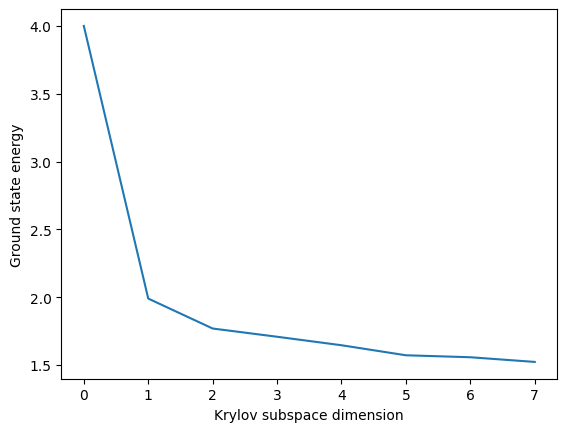

In [417]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-12)
plt.plot(GSEs)  # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")